In [227]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType

# CONFIGURAÇÕES

dataPath = "../data/players.xlsx"
modelPath = "../model/player-profile-clustering.onnx"

# TODO: definir melhor esses pesos com o cliente
weights = {
    "Distance (m)": 1.0,
    "High Intensity Running (m)": 1.0,
    "Sprint Distance (m)": 0.5,
    "Top Speed (kph)": 0.5,
    "Accelerations": 1.0,
    "Decelerations": 1.0,
    "Metres per Minute (m)": 1.0,
    "Explosividade": 1.5
}

minDistanceAvaliated = 1000
minDistanceExplosividade = 5000

metrics = [
    "Distance (m)",
    "High Intensity Running (m)",
    "Sprint Distance (m)",
    "Top Speed (kph)",
    "Accelerations",
    "Decelerations",
    "Metres per Minute (m)",
]

In [228]:
# CARREGAMENTO E FILTRAGEM DOS DADOS

df = pd.read_excel(dataPath)

ws = df[df["Segment Name"] == "Whole Session"].copy()
ws = ws[ws["Distance (m)"] > minDistanceAvaliated]

match_df = ws.dropna(subset=metrics).copy()

if match_df.shape[0] < 4:
    raise ValueError("Poucos dados para clustering")

print(f"Partidas carregadas: {match_df.shape[0]}")

Partidas carregadas: 644


In [229]:
# MÉTRICAS DERIVADAS

match_df["Explosividade"] = (
    match_df["Sprint Distance (m)"] / match_df["Distance (m)"]
) * match_df["Top Speed (kph)"]

match_df.loc[match_df['Distance (m)'] < minDistanceExplosividade, 'Explosividade'] = 0

metrics.append("Explosividade")

In [230]:
# NORMALIZAÇÃO

scaler = StandardScaler()
X = scaler.fit_transform(match_df[metrics])

X_normalized = pd.DataFrame(X, columns=metrics)

X_weighted = X_normalized * pd.Series(weights)

In [231]:
# TREINAMENTO DO MODELO

pipeline = Pipeline([("kmeans", KMeans(n_clusters=4, random_state=42, n_init=10))])

match_df["cluster"] = pipeline.fit_predict(X_weighted)
match_df["perfil"] = match_df["cluster"].map(cluster_names)

In [232]:
# MAPEAMENTO AUTOMÁTICO DOS CLUSTERS

centroids = match_df.groupby("cluster")[metrics].mean()

explosivo = centroids["Sprint Distance (m)"].idxmax()
baixo_volume = centroids["Distance (m)"].idxmin()

distancia_sem_explosivo = centroids["Distance (m)"].drop(index=explosivo)
resistente = distancia_sem_explosivo.idxmax()

moderado = [i for i in range(4) if i not in [explosivo, baixo_volume, resistente]][0]

cluster_names = {
    explosivo: "Explosivo",
    resistente: "Resistente",
    moderado: "Moderado",
    baixo_volume: "Baixo Volume",
}

print("Mapeamento automático dos clusters:")
for cluster, nome in cluster_names.items():
    print(f"  Cluster {cluster} → {nome}")

match_df["perfil"] = match_df["cluster"].map(cluster_names)
print(f"\nDistribuição:")
print(match_df["perfil"].value_counts())

Mapeamento automático dos clusters:
  Cluster 3 → Explosivo
  Cluster 1 → Resistente
  Cluster 2 → Moderado
  Cluster 0 → Baixo Volume

Distribuição:
perfil
Resistente      191
Moderado        190
Baixo Volume    167
Explosivo        96
Name: count, dtype: int64


In [233]:
# EXPORTAÇÃO DO MODELO

initial_type = [("float_input", FloatTensorType([None, len(metrics)]))]

onnx_model = convert_sklearn(pipeline, initial_types=initial_type)

with open(modelPath, "wb") as f:
    f.write(onnx_model.SerializeToString())

print(f"Modelo salvo em: {modelPath}")
print(f"Mapeamento de clusters: {cluster_names}")

Modelo salvo em: ../model/player-profile-clustering.onnx
Mapeamento de clusters: {np.int32(3): 'Explosivo', np.int32(1): 'Resistente', 2: 'Moderado', np.int32(0): 'Baixo Volume'}


<hr>

Variância explicada: 88.19%


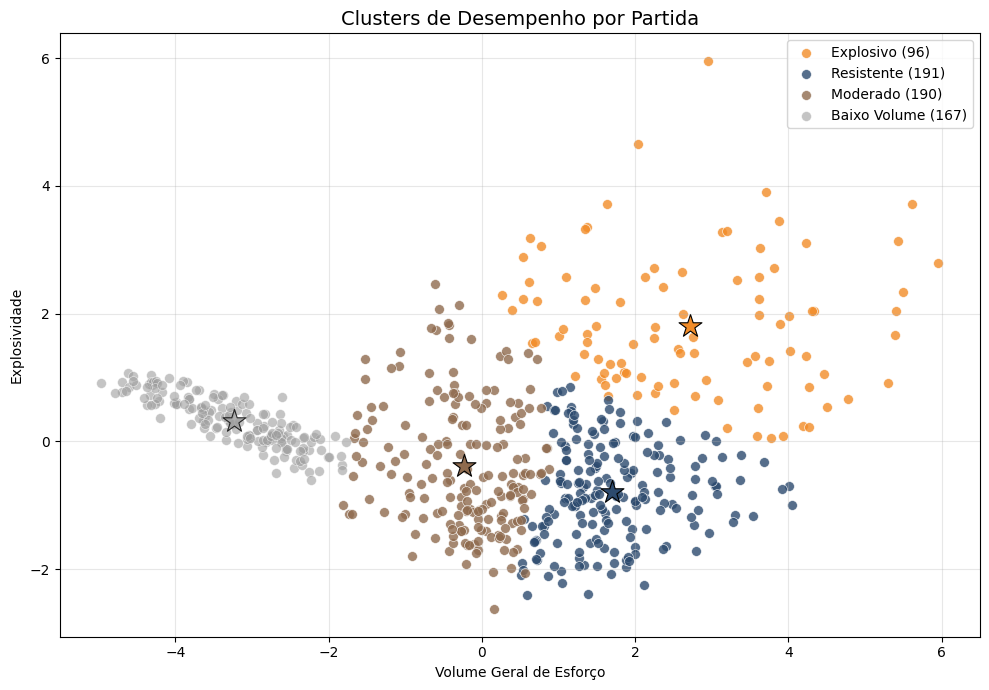

In [234]:
# VISUALIZAÇÃO DOS CLUSTERS

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_weighted)

print(f"Variância explicada: {pca.explained_variance_ratio_.sum():.2%}")

colors = {
    "Explosivo": "#F28C28",
    "Resistente": "#2C4A6E",
    "Moderado": "#8F6B4E",
    "Baixo Volume": "#9E9E9E",
}

plt.figure(figsize=(10, 7))

for perfil, color in colors.items():
    mask = match_df["perfil"] == perfil
    
    alpha = 0.8
    if perfil == "Baixo Volume":
        alpha = 0.6
    
    plt.scatter(
        X_2d[mask, 0],
        X_2d[mask, 1],
        c=color,
        label=f"{perfil} ({mask.sum()})",
        alpha=alpha,
        edgecolors="white",
        linewidths=0.5,
        s=50,
    )

for cluster, perfil in cluster_names.items():
    mask = match_df["cluster"].values == cluster
    centroid = X_weighted[mask].mean()
    centroid_2d = pca.transform(pd.DataFrame([centroid], columns=metrics))
    
    alpha = 1
    if perfil == "Baixo Volume":
        alpha = 0.8
        
    plt.scatter(
        centroid_2d[0, 0],
        centroid_2d[0, 1],
        c=colors[perfil],
        marker="*",
        alpha=alpha,
        s=300,
        edgecolors="black",
        linewidths=0.8,
    )

plt.title("Clusters de Desempenho por Partida", fontsize=14)
plt.xlabel("Volume Geral de Esforço")
plt.ylabel("Explosividade")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
# plt.savefig('../model/clusters.png', dpi=150)
plt.show()